In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from datetime import datetime, timedelta
import polars as pl

from thrs.control.modules.fahrenheit import FahrenheitControl, FahrenheitParameters
from thrs.input_output.alarms import BaseAlarms
from thrs.input_output.base import Stamped
from thrs.input_output.definitions.simulation import (
    Boundary,
    TemperatureBoundary,
    Fahrenheit,
)
from thrs.input_output.modules.fahrenheit import (
    FahrenheitControlValues,
    FahrenheitSensorValues,
    FahrenheitSimulationInputs,
    FahrenheitSimulationOutputs,
)
from thrs.orchestration.simulator import Simulator, SimulatorModel
from thrs.simulation.models.fmu_paths import fahrenheit_path

start_time = datetime.fromtimestamp(0)
minutes = 5
duration = timedelta(minutes=minutes - 1)
time_index = pl.datetime_range(
    start_time,
    start_time + duration,
    interval="1m",
    time_unit="us",
    eager=True,
)


simulation_inputs = FahrenheitSimulationInputs(
    fahrenheit_cold_supply=TemperatureBoundary(temperature=Stamped.stamp(20.0)),
    fahrenheit_seawater_supply=Boundary(
        temperature=Stamped.stamp(32.0), flow=Stamped.stamp(64.0)
    ),
    fahrenheit_available_cold_temperature=TemperatureBoundary(
        temperature=Stamped.stamp(20.0)
    ),
    fahrenheit_available_hot_temperature=TemperatureBoundary(
        temperature=Stamped.stamp(65.0)
    ),
    fahrenheit_available_seawater_temperature=TemperatureBoundary(
        temperature=Stamped.stamp(30.0)
    ),
    fahrenheit_chiller=Fahrenheit(free_cooling=Stamped.stamp(False)),
    fahrenheit_ht_supply=Boundary(
        temperature=Stamped.stamp(60.0), flow=Stamped.stamp(42.0)
    ),
    fahrenheit_boilers_supply=Boundary(
        temperature=Stamped.stamp(40.0), flow=Stamped.stamp(45.0)
    ),
)

parameters = FahrenheitParameters(
    chiller_enabled=True,
    waste_cooling_temperature_setpoint=10.0,
    waste_recovery_temperature_setpoint=40.0,
    hot_supply_temperature_setpoint=60.0,
    fahrenheit_cooling_setpoint=17.0,
    fahrenheit_hot_minimum=50.0,
    fahrenheit_hot_trigger=55.0,
    fahrenheit_cold_minimum=10.0,
    fahrenheit_cold_trigger=17.0,
    hot_mix_tuning=(0.05, 0.001, 0),
    recovery_tuning=(0.05, 0.001, 0),
    waste_cooling_tuning=(0.05, 0.01, 0),
    free_cooling_enabled=False,
)

fahrenheit_model = SimulatorModel(
    fmu_path=fahrenheit_path,
    sensor_values_cls=FahrenheitSensorValues,
    control_values_cls=FahrenheitControlValues,
    simulation_outputs_cls=FahrenheitSimulationOutputs,
    simulation_inputs=simulation_inputs,
    control_cls=FahrenheitControl,
    control_parameters=parameters,
    alarms=BaseAlarms(),
    tick_duration=timedelta(seconds=1),
    start_time=start_time,
)
with fahrenheit_model.executor() as executor:
    simulation = Simulator.from_model(fahrenheit_model, executor)
    result = await simulation.run(int(duration.total_seconds()))

  Variable fahrenheit_Module.fahrenheit.fahrenheit_Control.hysteresisCold.y = 1 at time 0
  Variable fahrenheit_Module.fahrenheit.fahrenheit_Control.zwitchCondition.state1.state_off_waitingForActivation.localActive = 1 at time 0
  Variable fahrenheit_Module.fahrenheit.fahrenheit_Control.zwitchCondition.state1.state_off_waitingForActivation.newActive = 1 at time 0
  Variable fahrenheit_Module.fahrenheit.fahrenheit_Control.zwitchCondition.state1.state_off_waitingForActivation.oldActive = 1 at time 0
  Variable fahrenheit_Module.fahrenheit.fahrenheit_Control.hysteresisCold.y = 1 at time 0
[WARNING] State logging: Please enable result storing to get state names
  Variable fahrenheit_Module.fahrenheit.fahrenheit_Control.hysteresisCold.y = 1 at time 0
  Variable fahrenheit_Module.fahrenheit.fahrenheit_Control.zwitchCondition.state1.state_off_waitingForActivation.localActive = 1 at time 0
  Variable fahrenheit_Module.fahrenheit.fahrenheit_Control.zwitchCondition.state1.state_off_waitingForAct

FMICallException: fmi2DoStep failed with status 3 (error).

/Users/alje/Repos/zero/zero-thrs-control/analysis/analysis_utils.py:407: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(
/Users/alje/Repos/zero/zero-thrs-control/analysis/analysis_utils.py:407: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


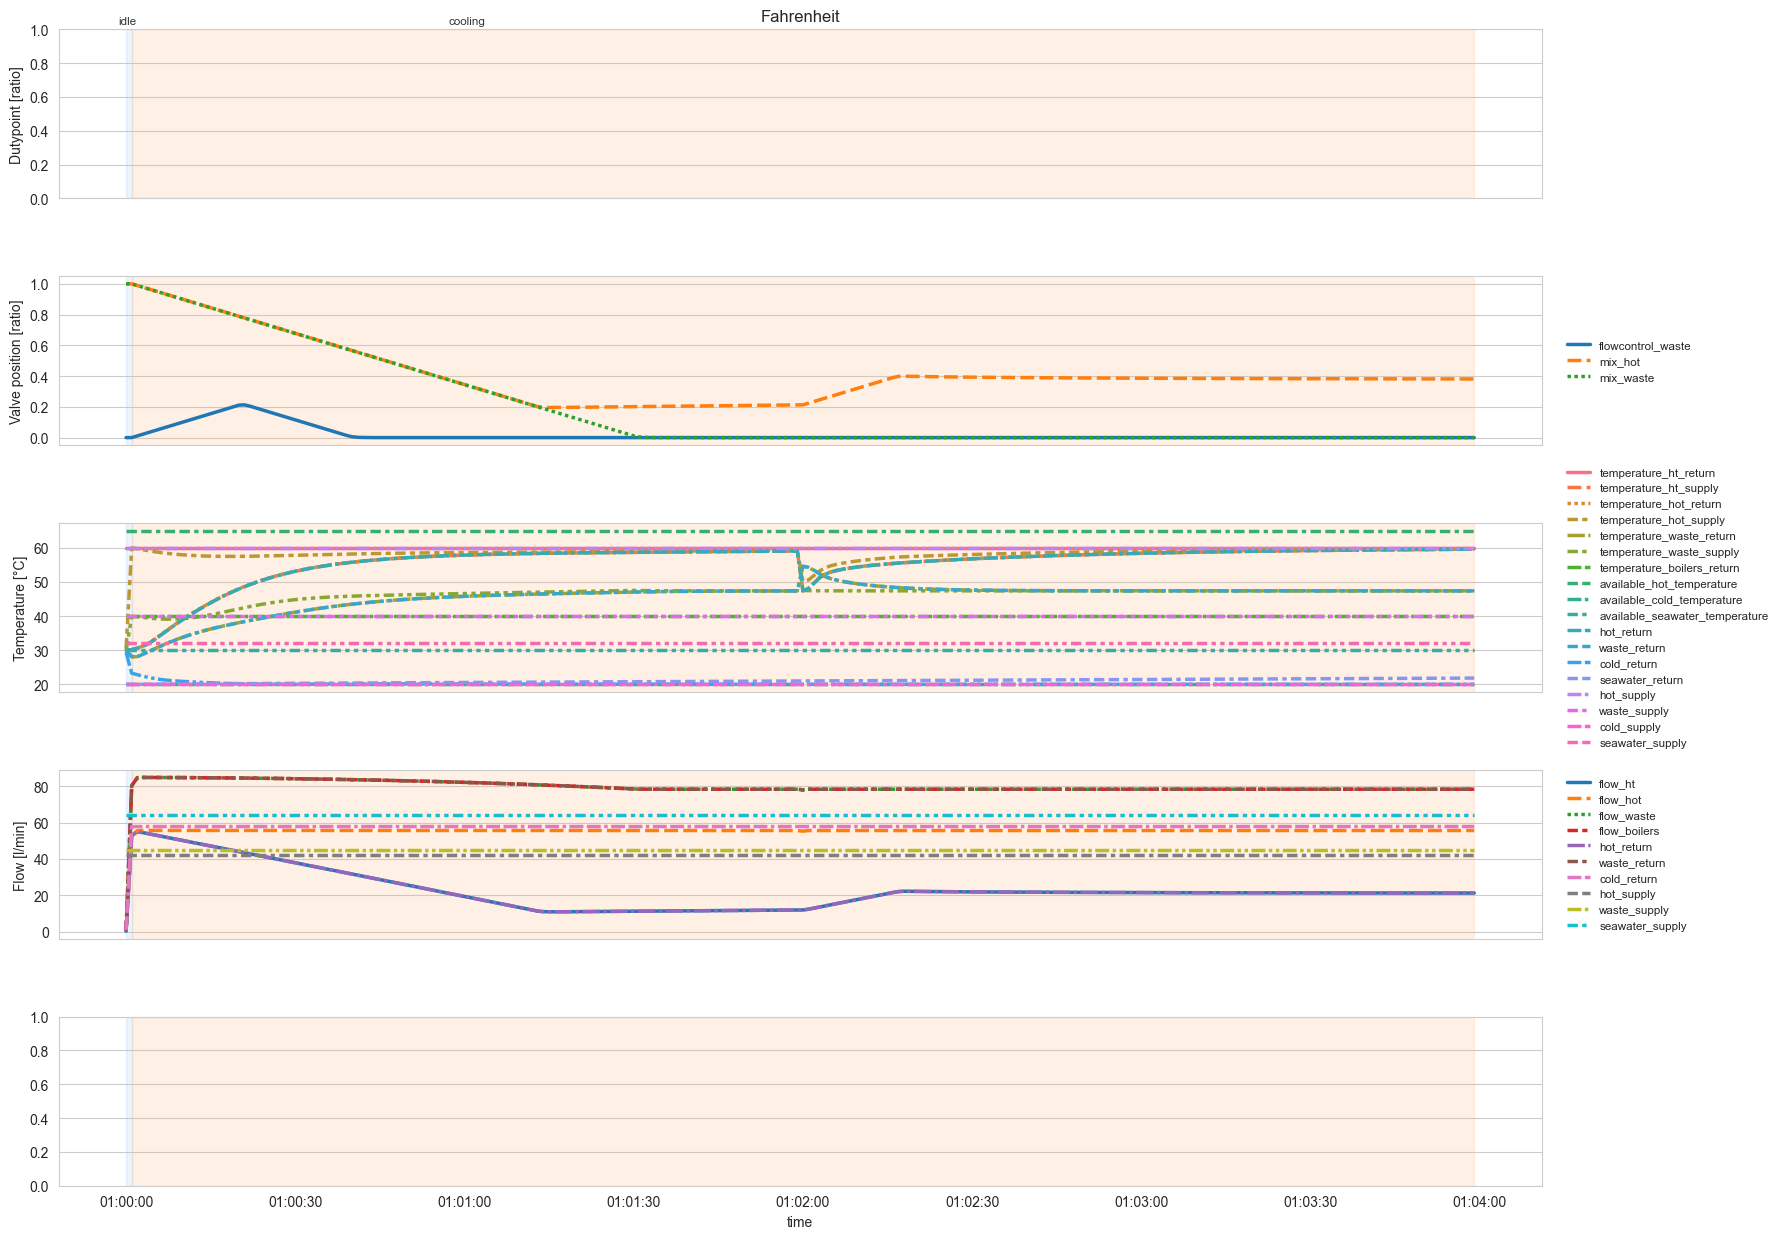

In [19]:
from analysis.analysis_utils import plot_result

plot_result(result, "plots/fahrenheit.png");

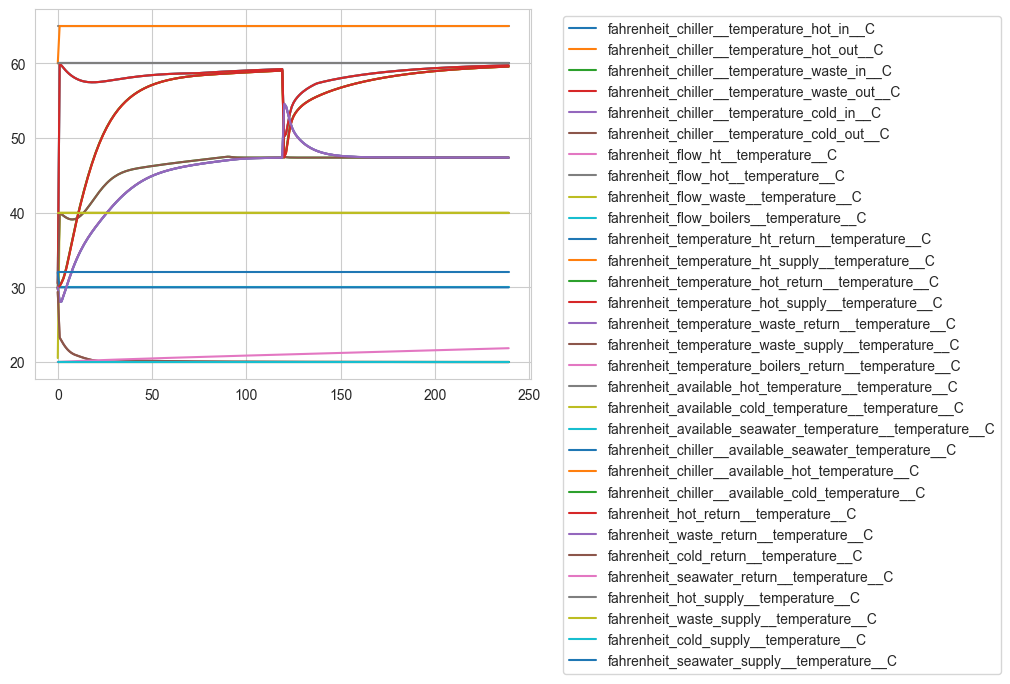

In [22]:
ax = result[[x for x in result.columns if "temperature" in x]].to_pandas().plot()
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

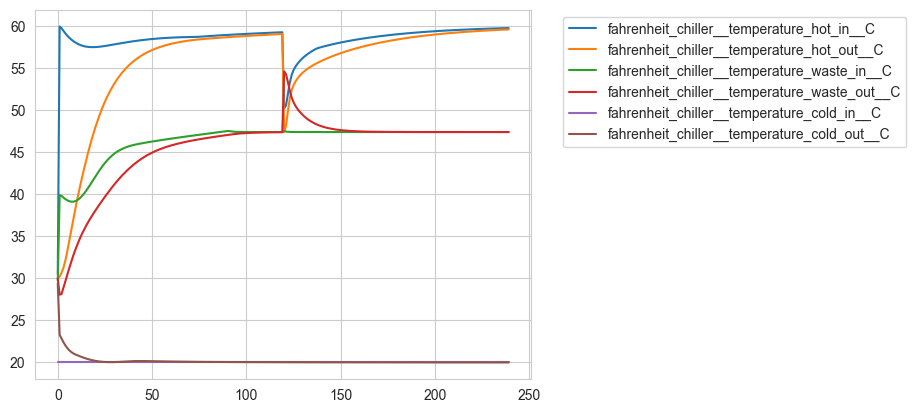

In [23]:
ax = (
    result[[x for x in result.columns if "fahrenheit_chiller__temperature" in x]]
    .to_pandas()
    .plot()
)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

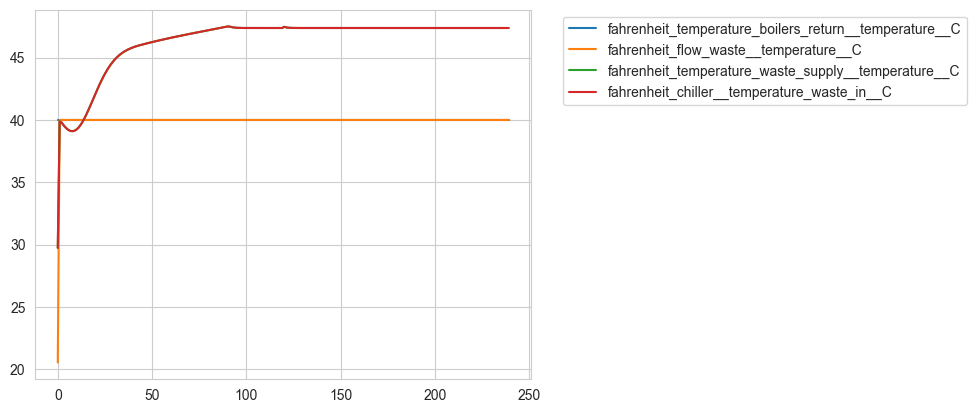

In [25]:
ax = (
    result[
        [
            "fahrenheit_temperature_boilers_return__temperature__C",
            "fahrenheit_flow_waste__temperature__C",
            "fahrenheit_temperature_waste_supply__temperature__C",
            "fahrenheit_chiller__temperature_waste_in__C",
        ]
    ]
    .to_pandas()
    .plot()
)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

In [28]:
result[
    [
        "fahrenheit_temperature_boilers_return__temperature__C",
        "fahrenheit_flow_waste__temperature__C",
        "fahrenheit_temperature_waste_supply__temperature__C",
        "fahrenheit_chiller__temperature_waste_in__C",
    ]
]

fahrenheit_temperature_boilers_return__temperature__C,fahrenheit_flow_waste__temperature__C,fahrenheit_temperature_waste_supply__temperature__C,fahrenheit_chiller__temperature_waste_in__C
f64,f64,f64,f64
40.0,20.536735,29.731698,29.731698
40.0,39.997517,39.875677,39.875677
40.0,40.0,39.798691,39.798691
40.0,40.0,39.59733,39.59733
40.0,40.0,39.418943,39.418943
…,…,…,…
40.0,40.0,47.380547,47.380547
40.0,40.0,47.380547,47.380547
40.0,40.0,47.380547,47.380547


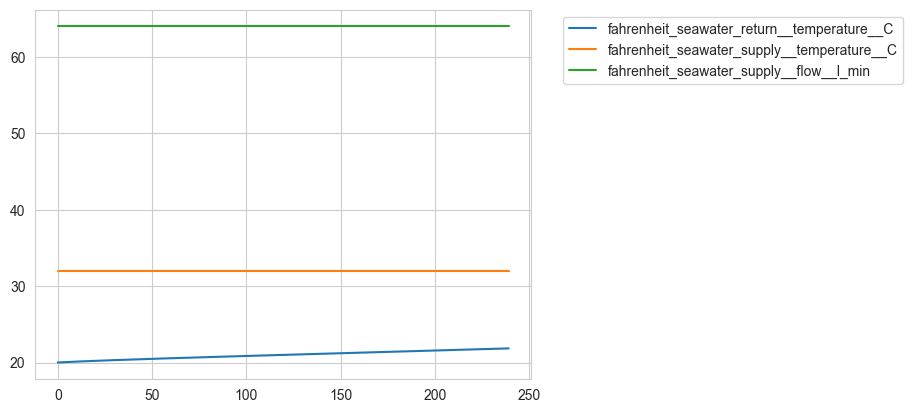

In [ ]:
ax = (
    result[[x for x in result.columns if ("seawater" in x) and "available" not in x]]
    .to_pandas()
    .plot()
)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

In [8]:
from thrs.simulation.io_mapping import flatten_model_values


result.select(
    [
        "time",
        *flatten_model_values(FahrenheitControlValues.zero(), fmu_only=False).keys(),
        *flatten_model_values(FahrenheitSimulationInputs.zero(), fmu_only=False).keys(),
    ]
).write_csv("csv/fahrenheit_run_inputs.csv")


result.select(
    [
        "time",
        *flatten_model_values(FahrenheitSensorValues.zero(), fmu_only=False).keys(),
        *flatten_model_values(
            FahrenheitSimulationOutputs.zero(), fmu_only=False
        ).keys(),
    ]
).write_csv("csv/fahrenheit_run_outputs.csv")

- figure out available-hot-temp etc to be included as simulation inputs and then passed on to sensor values and then to control values?? as control params?? as sensor values?? how does it work for other modules? <- ignore the fahrenheit outputs for now.. 
- deal with field_meta(included_in_fmu=False) 
- how to deal with sensor values that are not in fmu..? need to be passed as simulation inputs..? or set them with default values? <- pass as simulation inputs 
- remove tank temperature for fahrenheit_chiller sensor values? <- yes 
- 500 l/min on water loop? <- due to overpressure 
- overpressure values? <- do we need them? 
- what's with all the logging messages?  
- fahrenheit_available_hot_temperature and cold_tempeature should not be included in fmu..? (adapt in sheet)
- should the cold supply be an overpressure boundary or just a boundary? 
- write a test for bypassing fmu and injecting simulationvalues into sensors? 
- mix hot and mix waste going right way? 
- deal with free cooling mode.. 
- update not only tuning but also setpoint of controllers.. 
- change names of 'hot, cold, waste' temp values to 'available'. Should prob be fixed in fmu. 
- seawater return temp gets really high? 
- 